In [9]:
from ultralytics import SAM

# Load the model
model = SAM("mobile_sam.pt")
model.info()

Model summary: 251 layers, 10,130,092 parameters, 10,130,092 gradients


(251, 10130092, 10130092, 0.0)

In [2]:
sherds_root = "./"

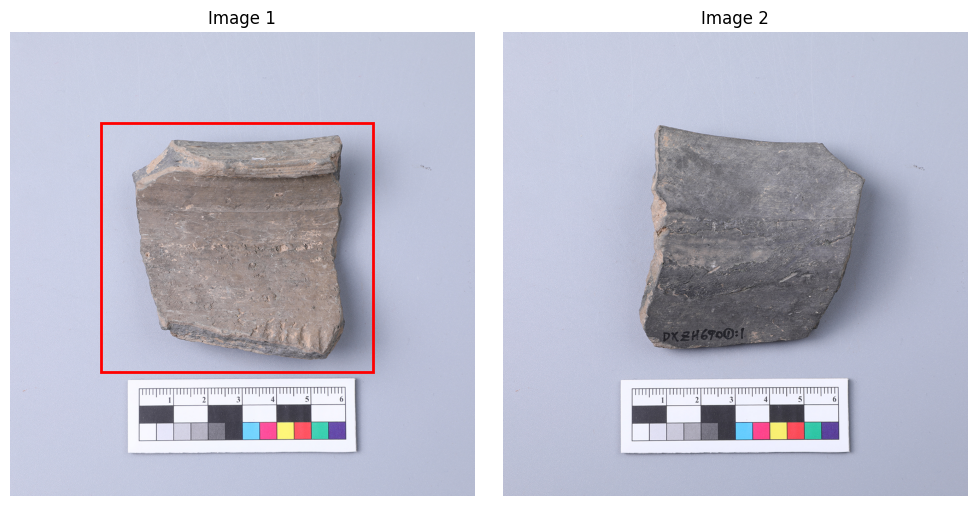

In [62]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

img1 = cv2.imread(os.path.join(sherds_root, 'h690/sherd_images/JD00001_exterior.jpg'))
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

img2 = cv2.imread(os.path.join(sherds_root, 'h690/sherd_images/JD00001_interior.jpg'))
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

# 顯示第一張圖片
axes[0].imshow(img1)
axes[0].set_title('Image 1')
axes[0].axis('off')

# 顯示第二張圖片
axes[1].imshow(img2)
axes[1].set_title('Image 2')
axes[1].axis('off')

bbox = (200, 200, 600, 550)
rect = patches.Rectangle((bbox[0], bbox[1]), bbox[2], bbox[3], linewidth=2, edgecolor='r', facecolor='none')

# 3. 將方框添加到繪圖區域
axes[0].add_patch(rect)

plt.tight_layout() # 自動調整間距，避免標題重疊
plt.show()


In [41]:
# Run inference with bboxes prompt
bboxes = [bbox[0], bbox[1], bbox[0] + bbox[2], bbox[1] + bbox[3]]
results = model(img1, bboxes=bboxes)


0: 1024x1024 1 0, 522.3ms
Speed: 10.6ms preprocess, 522.3ms inference, 1.3ms postprocess per image at shape (1, 3, 1024, 1024)


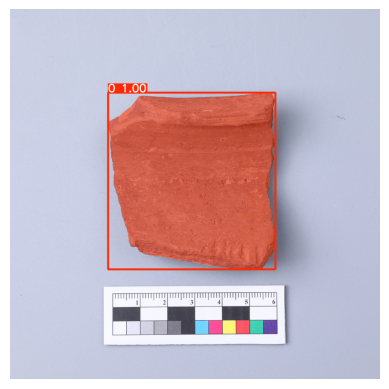

In [42]:
fig, ax = plt.subplots(1)
annotated_img = results[0].plot()  # 返回 RGB NumPy 陣列
plt.imshow(annotated_img)

ax.axis('off')
plt.show()

In [45]:
points = [bbox[0] + bbox[2] / 2, bbox[1] + bbox[3] / 2]
results = model(img2, points=points)


0: 1024x1024 1 0, 553.0ms
Speed: 5.5ms preprocess, 553.0ms inference, 1.3ms postprocess per image at shape (1, 3, 1024, 1024)


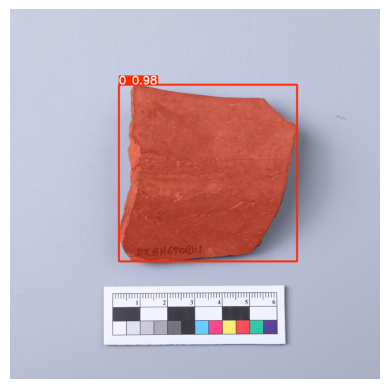

In [46]:
fig, ax = plt.subplots(1)
annotated_img = results[0].plot()  # 返回 RGB NumPy 陣列
plt.imshow(annotated_img)

ax.axis('off')
plt.show()

In [65]:
results[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0.])
conf: tensor([0.9767])
data: tensor([[301.0000, 209.0000, 794.0000, 698.0000,   0.9767,   0.0000]])
id: None
is_track: False
orig_shape: (1024, 1024)
shape: torch.Size([1, 6])
xywh: tensor([[547.5000, 453.5000, 493.0000, 489.0000]])
xywhn: tensor([[0.5347, 0.4429, 0.4814, 0.4775]])
xyxy: tensor([[301., 209., 794., 698.]])
xyxyn: tensor([[0.2939, 0.2041, 0.7754, 0.6816]])